# Phase 1: Data Loading and Preprocessing

This notebook walks through the Phase 1 pipeline step-by-step:
1. Loading raw algorithm data
2. Preprocessing and cleaning
3. Computing returns and equity curves
4. Feature engineering
5. Validating outputs

In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

%matplotlib inline

## 1. Data Discovery

First, let's explore what raw data we have available.

In [7]:
# Paths
from src.utils.paths import data_paths, output_paths
dp = data_paths()
op = output_paths()

# Backward-compatible aliases
RAW_DATA_PATH = dp.raw.root
PROCESSED_DATA_PATH = dp.processed.root

print("Raw data directories:")
for item in sorted(RAW_DATA_PATH.iterdir()):
    if item.is_dir():
        n_files = len(list(item.glob("*")))
        print(f"  {item.name}/: {n_files} files")

Raw data directories:
  algoritmos/: 14761 files
  benchmark/: 3 files
  commodities/: 13 files
  forex/: 170 files
  futures/: 2 files
  indices/: 10 files
  sharadar/: 2 files


In [8]:
# Count algorithm files
algo_path = RAW_DATA_PATH / 'algorithms'
if algo_path.exists():
    algo_files = list(algo_path.glob('*.csv'))
    print(f"Found {len(algo_files)} algorithm CSV files")
    print(f"\nSample files: {[f.name for f in algo_files[:5]]}")

## 2. Load Sample Algorithm

Let's load and examine a single algorithm to understand the data format.

In [9]:
from src.data.loader import DataLoader

loader = DataLoader(str(RAW_DATA_PATH))

# List available algorithms
available_algos = loader.list_algorithms()
print(f"Available algorithms: {len(available_algos)}")
print(f"Sample: {available_algos[:10]}")

Available algorithms: 14761
Sample: ['007XY', '00eyz', '00kZg', '00lLe', '00stS', '00ufq', '00wTX', '00Zqs', '01Jgc', '01wS7']


In [10]:
# Load a sample algorithm
if available_algos:
    sample_algo_id = available_algos[0]
    sample_algo = loader.load_algorithm(sample_algo_id)
    
    # AlgorithmData has: algo_id, ohlc (DataFrame), raw_path
    ohlc_df = sample_algo.ohlc
    
    print(f"Algorithm: {sample_algo.algo_id}")
    print(f"Raw path: {sample_algo.raw_path}")
    print(f"OHLC Shape: {ohlc_df.shape}")
    print(f"Date range: {ohlc_df.index.min()} to {ohlc_df.index.max()}")
    print(f"\nColumns: {list(ohlc_df.columns)}")
    print(f"\nHead:")
    display(ohlc_df.head())
    print(f"\nTail:")
    display(ohlc_df.tail())

Algorithm: 007XY
Raw path: ..\data\raw\algoritmos\007XY.csv
OHLC Shape: (574, 4)
Date range: 2022-03-14 00:00:00 to 2024-02-04 00:00:00

Columns: ['open', 'high', 'low', 'close']

Head:


,open,high,low,close
datetime,,,,
2022-03-14,100.61,100.61,100.61,100.61
2022-03-15,100.61,100.61,100.61,100.61
2022-03-16,100.61,100.61,100.61,100.61
2022-03-17,100.61,100.61,100.61,100.61
2022-03-18,100.61,100.61,100.61,100.61



Tail:


,open,high,low,close
datetime,,,,
2024-01-30,89.92,89.92,89.92,89.92
2024-01-31,89.92,89.92,89.92,89.92
2024-02-01,89.92,89.92,89.92,89.92
2024-02-02,89.92,89.92,89.92,89.92
2024-02-04,89.92,89.92,89.92,89.92


In [11]:
# Data quality check
if available_algos:
    print("Data Quality Summary:")
    print(f"  Missing values per column:")
    print(ohlc_df.isna().sum())
    print(f"\n  Data types:")
    print(ohlc_df.dtypes)
    print(f"\n  Basic statistics:")
    display(ohlc_df.describe())

Data Quality Summary:
  Missing values per column:
open     0
high     0
low      0
close    0
dtype: int64

  Data types:
open     float64
high     float64
low      float64
close    float64
dtype: object

  Basic statistics:


,open,high,low,close
count,574.000000,574.000000,574.000000,574.000000
mean,91.150871,91.215070,91.083188,91.132456
std,2.762074,2.878197,2.652016,2.734370
min,89.920000,89.920000,89.660000,89.920000
25%,89.920000,89.920000,89.920000,89.920000
50%,89.920000,89.920000,89.920000,89.920000
75%,89.920000,89.920000,89.920000,89.920000
max,100.610000,100.630000,100.610000,100.610000


## 3. Preprocessing

Apply preprocessing to compute returns and equity curves.

In [12]:
from src.data.preprocessor import DataPreprocessor

preprocessor = DataPreprocessor()

if available_algos:
    # Process the sample algorithm (pass the AlgorithmData object)
    processed = preprocessor.process_algorithm(sample_algo)
    
    print(f"Processed Algorithm: {processed.algo_id}")
    print(f"Returns shape: {processed.returns.shape if processed.returns is not None else 'None'}")
    print(f"Equity curve shape: {processed.equity_curve.shape if processed.equity_curve is not None else 'None'}")
    
    if processed.returns is not None:
        print(f"\nReturns statistics:")
        print(f"  Mean daily return: {processed.returns.mean():.6f}")
        print(f"  Std daily return: {processed.returns.std():.6f}")
        print(f"  Min: {processed.returns.min():.4f}")
        print(f"  Max: {processed.returns.max():.4f}")

Processed Algorithm: 007XY
Returns shape: (573,)
Equity curve shape: (574,)

Returns statistics:
  Mean daily return: -0.000193
  Std daily return: 0.002495
  Min: -0.0152
  Max: 0.0205


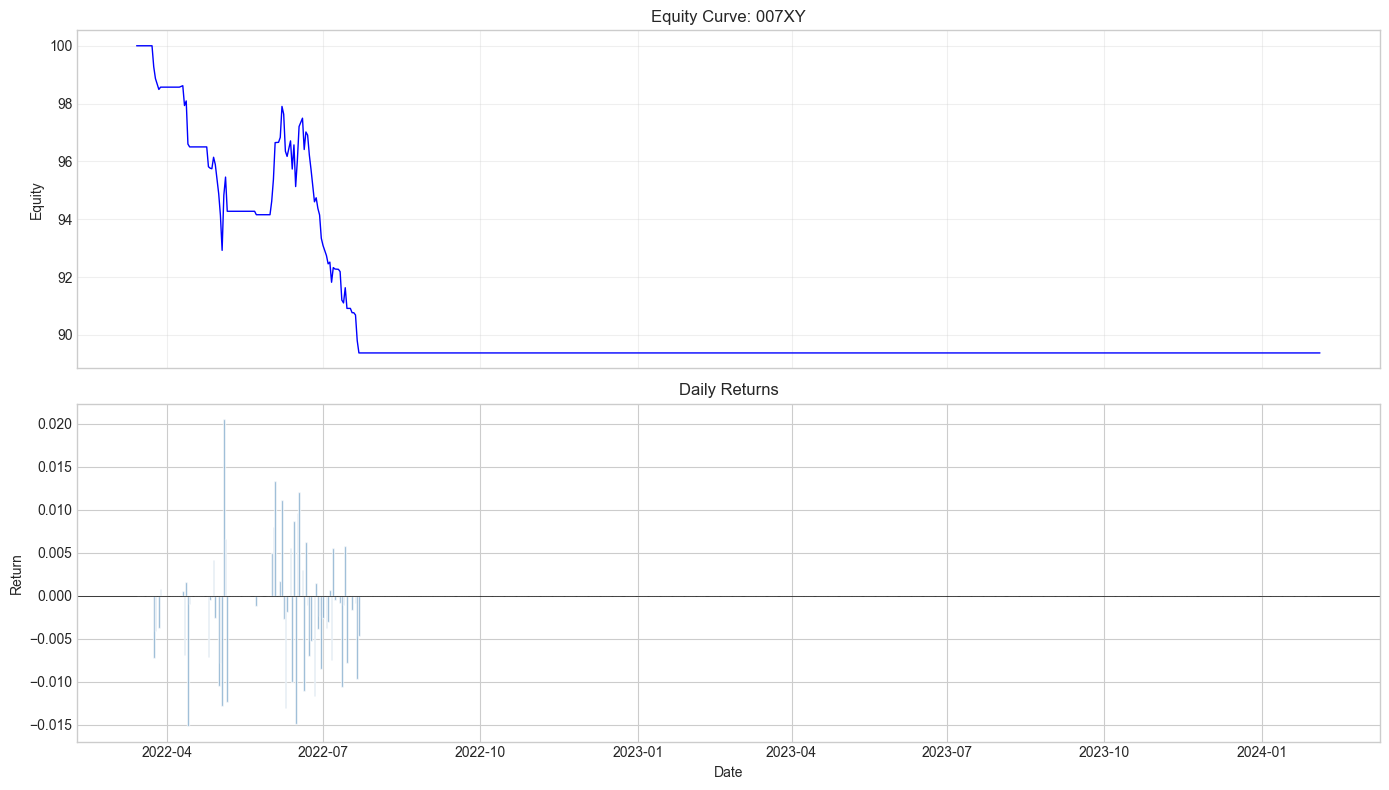

In [13]:
# Plot equity curve
if available_algos and processed.equity_curve is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Equity curve
    axes[0].plot(processed.equity_curve.index, processed.equity_curve.values, 'b-', linewidth=1)
    axes[0].set_title(f'Equity Curve: {sample_algo_id}')
    axes[0].set_ylabel('Equity')
    axes[0].grid(True, alpha=0.3)
    
    # Returns
    if processed.returns is not None:
        axes[1].bar(processed.returns.index, processed.returns.values, color='steelblue', alpha=0.7, width=1)
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axes[1].set_title('Daily Returns')
        axes[1].set_ylabel('Return')
        axes[1].set_xlabel('Date')
    
    plt.tight_layout()
    plt.show()

## 4. Load Processed Data (Phase 1 Output)

If Phase 1 has already been run, load the processed data.

In [14]:
# Check what processed files exist
print("Processed data files:")
if PROCESSED_DATA_PATH.exists():
    for f in sorted(PROCESSED_DATA_PATH.glob('*')):
        if f.is_file():
            size_mb = f.stat().st_size / (1024 * 1024)
            print(f"  {f.name}: {size_mb:.2f} MB")
else:
    print("  No processed data directory found. Run Phase 1 first.")

Processed data files:
  algo_features.parquet: 647.70 MB
  algo_returns.parquet: 30.74 MB
  algo_stats.csv: 2.60 MB
  asset_inference.csv: 0.96 MB
  benchmark_algo_equity.parquet: 1.56 MB
  benchmark_algo_features.parquet: 25.48 MB
  benchmark_concentration.csv: 0.17 MB
  benchmark_daily_returns.csv: 0.05 MB
  benchmark_positions.parquet: 0.18 MB
  benchmark_turnover.csv: 0.07 MB
  benchmark_weights.parquet: 0.64 MB
  clustering_methods_comparison.csv: 0.00 MB
  cross_features.parquet: 0.03 MB
  monthly_analysis.csv: 0.05 MB
  PHASE1_DATA_LOADING_FINDINGS.md: 0.01 MB
  phase1_results.json: 0.00 MB
  PHASE1_SUMMARY.md: 0.00 MB
  regime_features.parquet: 0.04 MB


In [15]:
# Load returns matrix
if dp.algorithms.returns.exists():
    returns_matrix = pd.read_parquet(dp.algorithms.returns)
    print(f"Returns Matrix Shape: {returns_matrix.shape}")
    print(f"Date range: {returns_matrix.index.min()} to {returns_matrix.index.max()}")
    print(f"Number of algorithms: {len(returns_matrix.columns)}")
    print(f"
Missing values per algorithm (sample):")
    print(returns_matrix.isna().sum().describe())
else:
    print("Returns matrix not found. Run Phase 1 first.")
    returns_matrix = None

Returns Matrix Shape: (1430, 13513)
Date range: 2020-06-02 00:00:00 to 2024-12-30 00:00:00
Number of algorithms: 13513

Missing values per algorithm (sample):
count    13513.000000
mean       994.390069
std        414.923260
min          0.000000
25%        751.000000
50%       1169.000000
75%       1318.000000
max       1428.000000
dtype: float64


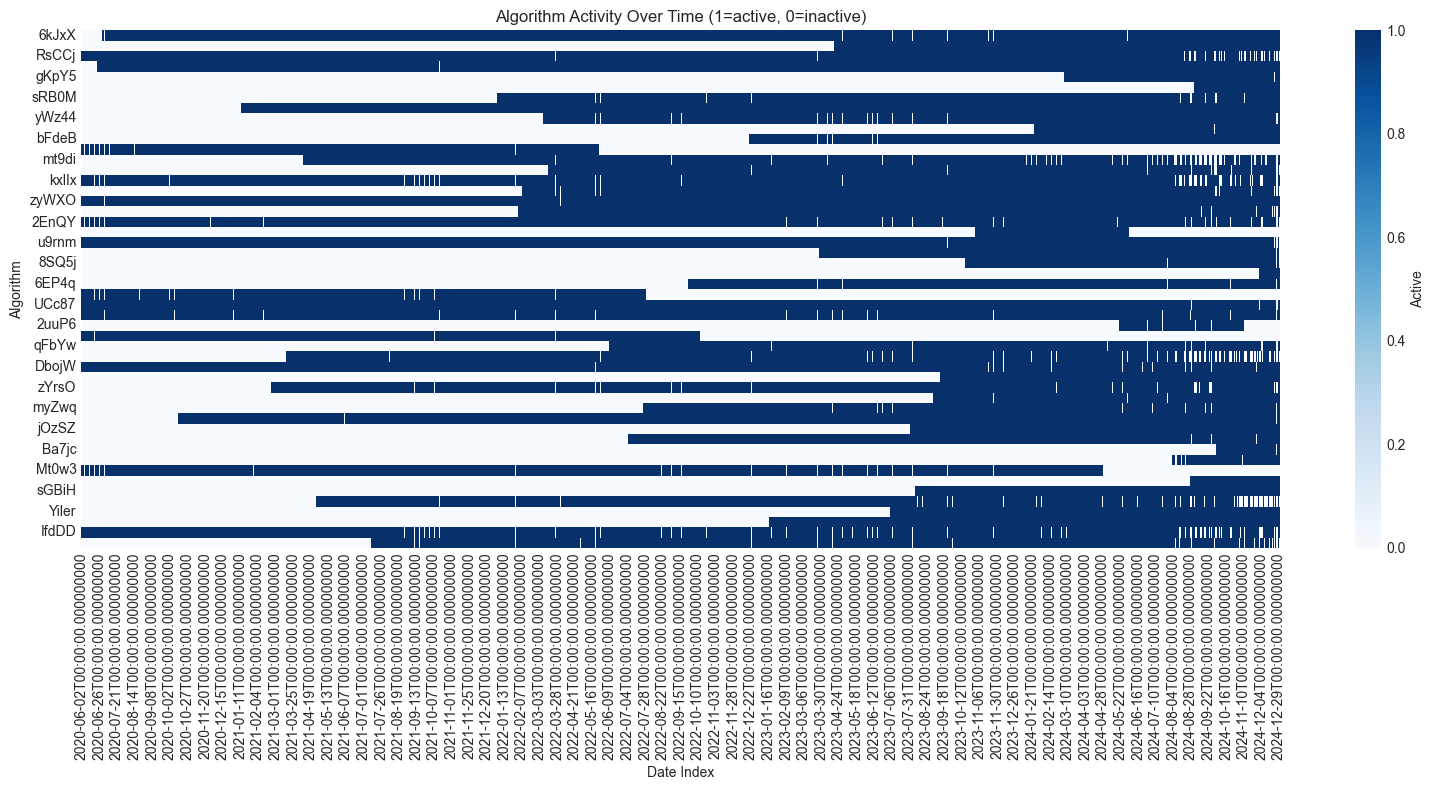

In [16]:
# Visualize returns matrix coverage
if returns_matrix is not None:
    # Activity heatmap (sample of algorithms)
    sample_cols = returns_matrix.columns[:50] if len(returns_matrix.columns) > 50 else returns_matrix.columns
    activity = returns_matrix[sample_cols].notna().astype(int)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    sns.heatmap(activity.T, cmap='Blues', cbar_kws={'label': 'Active'}, ax=ax)
    ax.set_title('Algorithm Activity Over Time (1=active, 0=inactive)')
    ax.set_xlabel('Date Index')
    ax.set_ylabel('Algorithm')
    plt.tight_layout()
    plt.show()

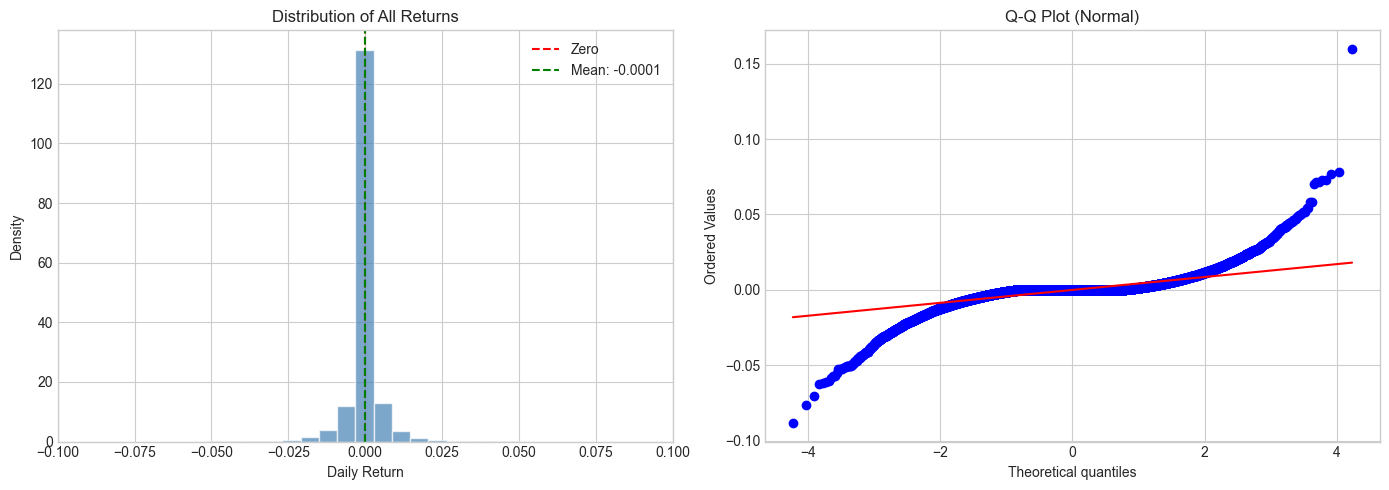

Returns Statistics:
  Mean: -0.000103
  Std: 0.005399
  Skewness: -0.8481
  Kurtosis: 52.9167


In [17]:
# Returns distribution
if returns_matrix is not None:
    all_returns = returns_matrix.values.flatten()
    all_returns = all_returns[~np.isnan(all_returns)]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(all_returns, bins=100, density=True, alpha=0.7, color='steelblue')
    axes[0].axvline(x=0, color='red', linestyle='--', label='Zero')
    axes[0].axvline(x=np.mean(all_returns), color='green', linestyle='--', label=f'Mean: {np.mean(all_returns):.4f}')
    axes[0].set_title('Distribution of All Returns')
    axes[0].set_xlabel('Daily Return')
    axes[0].set_ylabel('Density')
    axes[0].legend()
    axes[0].set_xlim(-0.1, 0.1)
    
    # QQ plot
    from scipy import stats
    stats.probplot(all_returns[::100], dist="norm", plot=axes[1])  # Subsample for speed
    axes[1].set_title('Q-Q Plot (Normal)')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Returns Statistics:")
    print(f"  Mean: {np.mean(all_returns):.6f}")
    print(f"  Std: {np.std(all_returns):.6f}")
    print(f"  Skewness: {stats.skew(all_returns):.4f}")
    print(f"  Kurtosis: {stats.kurtosis(all_returns):.4f}")

## 5. Benchmark Data

Examine the benchmark data.

In [18]:
# Load benchmark returns
if dp.benchmark.daily_returns.exists():
    bench_returns = pd.read_csv(dp.benchmark.daily_returns, index_col=0, parse_dates=True)
    if "return" in bench_returns.columns:
        bench_returns = bench_returns["return"]
    else:
        bench_returns = bench_returns.iloc[:, 0]
    
    print(f"Benchmark Returns:")
    print(f"  Shape: {bench_returns.shape}")
    print(f"  Date range: {bench_returns.index.min()} to {bench_returns.index.max()}")
    print(f"  Mean daily return: {bench_returns.mean():.6f}")
    print(f"  Std daily return: {bench_returns.std():.6f}")
else:
    print("Benchmark returns not found.")
    bench_returns = None

Benchmark Returns:
  Shape: (1429,)
  Date range: 2020-06-03 00:00:00 to 2024-12-30 00:00:00
  Mean daily return: 0.000103
  Std daily return: 0.001718


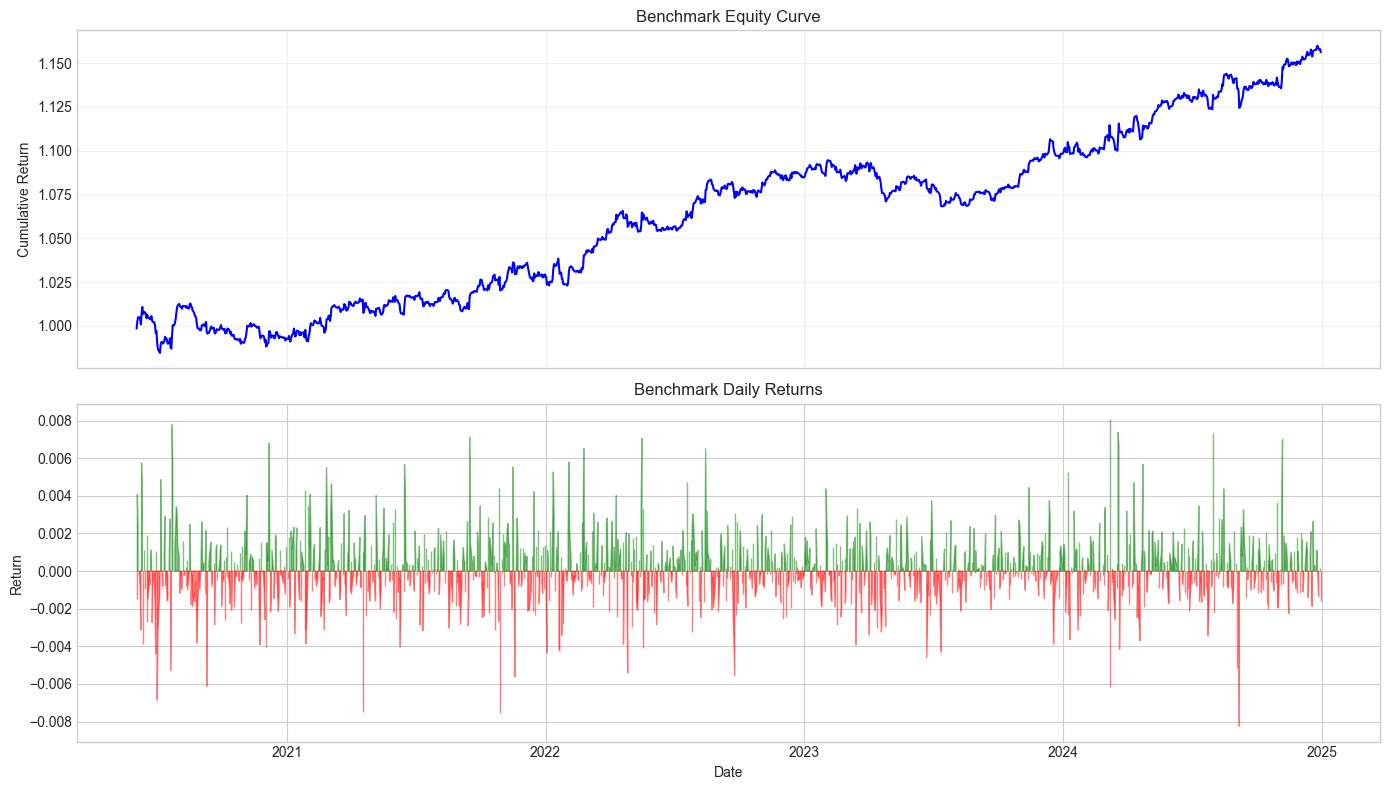

In [19]:
# Plot benchmark equity curve
if bench_returns is not None:
    bench_equity = (1 + bench_returns).cumprod()
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    axes[0].plot(bench_equity.index, bench_equity.values, 'b-', linewidth=1.5)
    axes[0].set_title('Benchmark Equity Curve')
    axes[0].set_ylabel('Cumulative Return')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].fill_between(bench_returns.index, bench_returns.values, 0, 
                         where=bench_returns.values >= 0, color='green', alpha=0.5)
    axes[1].fill_between(bench_returns.index, bench_returns.values, 0, 
                         where=bench_returns.values < 0, color='red', alpha=0.5)
    axes[1].set_title('Benchmark Daily Returns')
    axes[1].set_ylabel('Return')
    axes[1].set_xlabel('Date')
    
    plt.tight_layout()
    plt.show()

## 6. Summary Statistics

Compute summary statistics for the algorithm universe.

In [20]:
if returns_matrix is not None:
    # Per-algorithm statistics
    algo_stats = pd.DataFrame({
        'n_obs': returns_matrix.notna().sum(),
        'mean_return': returns_matrix.mean(),
        'std_return': returns_matrix.std(),
        'sharpe': returns_matrix.mean() / returns_matrix.std() * np.sqrt(252),
        'min_return': returns_matrix.min(),
        'max_return': returns_matrix.max(),
    })
    
    print("Algorithm Universe Statistics:")
    display(algo_stats.describe())

Algorithm Universe Statistics:


,n_obs,mean_return,std_return,sharpe,min_return,max_return
count,13513.000000,13513.000000,13513.000000,10255.000000,13513.000000,13513.000000
mean,435.609931,-0.000382,0.005148,-0.935815,-0.026565,0.022303
std,414.923260,0.001354,0.004156,2.294433,0.024176,0.020914
min,2.000000,-0.034678,0.000000,-27.842291,-0.288018,0.000000
25%,112.000000,-0.000422,0.001012,-1.523688,-0.039309,0.000000
50%,261.000000,-0.000045,0.005527,-0.555571,-0.025127,0.020296
75%,679.000000,0.000000,0.007367,0.106188,-0.003168,0.034206
max,1430.000000,0.008664,0.063020,23.450749,0.000000,0.305326


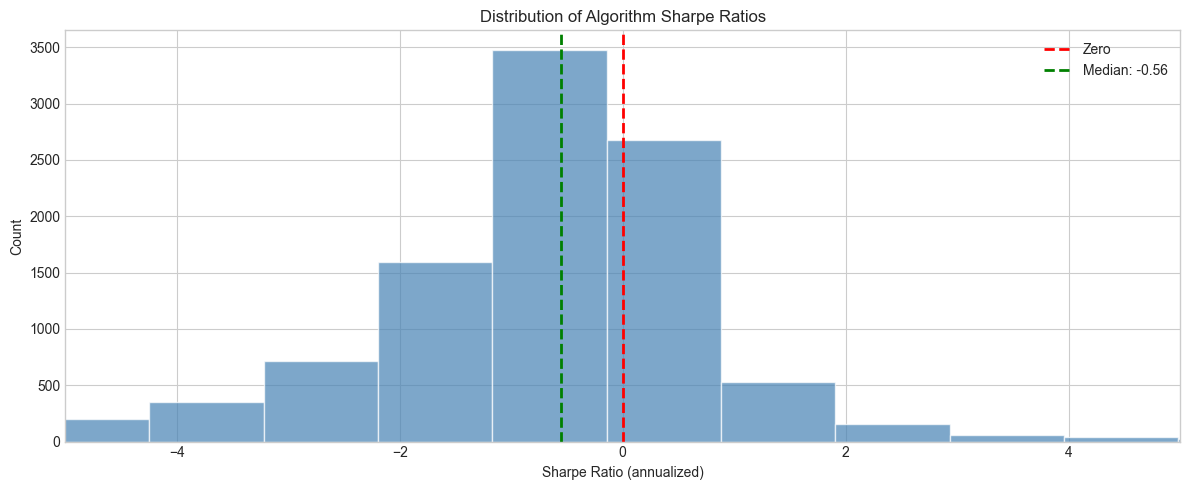


Sharpe Ratio Statistics:
  Positive Sharpe: 2933 (28.6%)
  Sharpe > 1: 741 (7.2%)
  Sharpe > 2: 295 (2.9%)


In [21]:
# Distribution of Sharpe ratios
if returns_matrix is not None:
    valid_sharpe = algo_stats['sharpe'].dropna()
    valid_sharpe = valid_sharpe[np.isfinite(valid_sharpe)]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(valid_sharpe, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    ax.axvline(x=valid_sharpe.median(), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {valid_sharpe.median():.2f}')
    ax.set_title('Distribution of Algorithm Sharpe Ratios')
    ax.set_xlabel('Sharpe Ratio (annualized)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.set_xlim(-5, 5)
    plt.tight_layout()
    plt.show()
    
    print(f"\nSharpe Ratio Statistics:")
    print(f"  Positive Sharpe: {(valid_sharpe > 0).sum()} ({(valid_sharpe > 0).mean()*100:.1f}%)")
    print(f"  Sharpe > 1: {(valid_sharpe > 1).sum()} ({(valid_sharpe > 1).mean()*100:.1f}%)")
    print(f"  Sharpe > 2: {(valid_sharpe > 2).sum()} ({(valid_sharpe > 2).mean()*100:.1f}%)")

## 7. Validation Checks

Verify data integrity and quality.

In [22]:
print("Data Validation Checks:")
print("=" * 50)

if returns_matrix is not None:
    # Check 1: No extreme returns
    extreme_threshold = 0.5  # 50% daily return is suspicious
    extreme_returns = (returns_matrix.abs() > extreme_threshold).sum().sum()
    print(f"1. Extreme returns (>50%): {extreme_returns}")
    
    # Check 2: Date continuity
    date_gaps = returns_matrix.index.to_series().diff().dt.days
    large_gaps = (date_gaps > 5).sum()  # Gaps > 5 days (excluding weekends)
    print(f"2. Large date gaps (>5 days): {large_gaps}")
    
    # Check 3: Algorithm with very few observations
    min_obs = 20
    low_obs_algos = (returns_matrix.notna().sum() < min_obs).sum()
    print(f"3. Algorithms with <{min_obs} observations: {low_obs_algos}")
    
    # Check 4: Constant returns (suspicious)
    zero_std_algos = (returns_matrix.std() == 0).sum()
    print(f"4. Algorithms with zero variance: {zero_std_algos}")
    
    # Check 5: Index is datetime
    print(f"5. Index type: {type(returns_matrix.index)}")
    
print("\nAll checks completed.")

Data Validation Checks:
1. Extreme returns (>50%): 0
2. Large date gaps (>5 days): 0
3. Algorithms with <20 observations: 663
4. Algorithms with zero variance: 3258
5. Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

All checks completed.


## Summary

Phase 1 data is ready for Phase 2 analysis if:
- Returns matrix is loaded successfully
- Benchmark returns are available
- No critical validation failures